# Caso de Estudio
## ¿Cuál es el comportamiento y la variabilidad temporal del recurso eólico en el departamento de La Guajira y qué efecto tiene sobre el potencial de generación de energía eléctrica?

Vamos a evaluar el comportomamiento y la variabilidad en el departamento de la Guajira, para así poder analizar el potencial de generación de energía eléctrica, además de responder estas pregguntas

In [31]:
#Libererías que vamos a usar
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Obtención de datos reales desde NASA POWER

NASA POWER es una platagorma que permite tomar información metereológica y climatológica para cualquier unicación del planeta

Vamos a descargar:

* Velocidad del viento a 2 metros (WS2M)

# Para descar los datos seguimos estos pasos:

* Solicitar los datos a la API de NASA.
* Recibir la respiesta en formaton JSON.
* Convertir el JSON a un Dataframe.
* Aplicar herramientas estadísticas para extraer conocimiento.

In [32]:
lat = 12.218014
lon = -72.059944

start_date = "20150101"
end_date = "20251231"

In [21]:
url = (
    "https://power.larc.nasa.gov/api/temporal/hourly/point"
    "?parameters=T2M,WS2M"
    "&community=RE"
    f"&latitude={lat}"
    f"&longitude={lon}"
    f"&start={start_date}"
    f"&end={end_date}"
    "&format=JSON"
)

url

'https://power.larc.nasa.gov/api/temporal/hourly/point?parameters=T2M,WS2M&community=RE&latitude=12.218014&longitude=-72.059944&start=20150101&end=20251231&format=JSON'

In [33]:
url = (
    "https://power.larc.nasa.gov/api/temporal/hourly/point"
    "?parameters=WS2M"
    "&community=RE"
    f"&latitude={lat}"
    f"&longitude={lon}"
    f"&start={start_date}"
    f"&end={end_date}"
    "&format=JSON"
)

response = requests.get(url)
data = response.json()

viento = data["properties"]["parameter"]["WS2M"]

df = pd.DataFrame({    
    "Velocidad_Viento": viento
})

# Conociendo el conjunto de datos

Antes de realizar calculos estadísticos o construir gráficos debemos conocer lo siguiente:

* Número de registros.
* Variables disponibles.
* Tipo de información.
* Calidad de los datos.

In [23]:
df.head()

,Velocidad_Viento
2015010100,7.03
2015010101,7.16
2015010102,7.11
2015010103,7.12
2015010104,7.21


In [24]:
df.info()

<class 'pandas.DataFrame'>
Index: 96432 entries, 2015010100 to 2025123123
Data columns (total 1 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Velocidad_Viento  96432 non-null  float64
dtypes: float64(1)
memory usage: 1.5+ MB


In [25]:
df.shape

(96432, 1)

# Convertir el JSON a una tabla

Para realizar un análisis mas facilmente realizamos esta transformación.

In [35]:
# Convertir JSON a un Dataframe

df = pd.DataFrame(
    response.json()["properties"]["parameter"]["WS2M"].items(),
    columns=["Fecha", "Velocidad_Viento"])

# Convertir la fecha a formato datetime
df["Fecha"] = pd.to_datetime(
    df["Fecha"], format="%Y%m%d%H"

)

df


,Fecha,Velocidad_Viento
0,2015-01-01 00:00:00,7.03
1,2015-01-01 01:00:00,7.16
2,2015-01-01 02:00:00,7.11
3,2015-01-01 03:00:00,7.12
4,2015-01-01 04:00:00,7.21
...,...,...
96427,2025-12-31 19:00:00,6.18
96428,2025-12-31 20:00:00,6.23
96429,2025-12-31 21:00:00,6.24
96430,2025-12-31 22:00:00,6.36


## Análisis exploratorio del recurso eólico

> El conjunto de datos contiene `Velocidad_Viento` (`WS2M`), por eso, el análisis siguiente estudia la velocidad del viento como indicador del recurso eólico. Si en el futuro se dispone también de la dirección del viento (`WD2M`), este análisis podría complementarse con una rosa de vientos que identifique las direcciones predominantes del recurso.

En esta sección se calculan estadísticas descriptivas, promedios por mes y año, variabilidad mensual, años y meses extremos, y la tendencia temporal.

In [36]:
# Preparación y validación de la serie temporal
# Se trabaja con una copia para conservar el DataFrame original.
analisis = df.copy()

analisis["Fecha"] = pd.to_datetime(analisis["Fecha"], errors="coerce")
analisis["Velocidad_Viento"] = pd.to_numeric(
    analisis["Velocidad_Viento"], errors="coerce"
)

analisis = (
    analisis.dropna(subset=["Fecha", "Velocidad_Viento"])
    .sort_values("Fecha")
    .set_index("Fecha")
)

# Los valores negativos no representan una velocidad física válida.
analisis.loc[analisis["Velocidad_Viento"] < 0, "Velocidad_Viento"] = np.nan
analisis = analisis.dropna(subset=["Velocidad_Viento"])

variable = "Velocidad_Viento"
unidad = "m/s"

print(f"Periodo analizado: {analisis.index.min():%Y-%m-%d} a {analisis.index.max():%Y-%m-%d}")
print(f"Registros válidos: {len(analisis):,}")
print(f"Datos faltantes en la variable: {analisis[variable].isna().sum():,}")
analisis.head()

Periodo analizado: 2015-01-01 a 2025-12-31
Registros válidos: 96,432
Datos faltantes en la variable: 0


,Velocidad_Viento
Fecha,
2015-01-01 00:00:00,7.03
2015-01-01 01:00:00,7.16
2015-01-01 02:00:00,7.11
2015-01-01 03:00:00,7.12
2015-01-01 04:00:00,7.21


In [37]:
# 1. Estadísticas descriptivas de la velocidad del viento
estadisticas = analisis[variable].describe().to_frame(name=variable)
estadisticas.loc["mediana"] = analisis[variable].median()
estadisticas.loc["coef_variacion_%"] = (
    analisis[variable].std() / analisis[variable].mean() * 100
)

print("Estadísticas descriptivas")
display(estadisticas.round(3))

Estadísticas descriptivas


,Velocidad_Viento
count,96432.000
mean,5.917
std,1.834
min,0.040
25%,4.770
50%,6.140
75%,7.270
max,10.900
mediana,6.140
coef_variacion_%,30.989


In [ ]:
#Promedios climatológicos por mes y por año
analisis["Año"] = analisis.index.year
analisis["Mes"] = analisis.index.month

nombres_meses = {
    1: "Enero", 2: "Febrero", 3: "Marzo", 4: "Abril",
    5: "Mayo", 6: "Junio", 7: "Julio", 8: "Agosto",
    9: "Septiembre", 10: "Octubre", 11: "Noviembre", 12: "Diciembre"
}

promedio_mensual = (
    analisis.groupby("Mes")[variable]
    .agg(Promedio="mean", Desviacion="std", Minimo="min", Maximo="max")
)
promedio_mensual["Mes"] = promedio_mensual.index.map(nombres_meses)
promedio_mensual = promedio_mensual[["Mes", "Promedio", "Desviacion", "Minimo", "Maximo"]]

promedio_anual = (
    analisis.groupby("Año")[variable]
    .agg(Promedio="mean", Desviacion="std", Minimo="min", Maximo="max", Registros="count")
    .sort_index()
)

print("Promedio climatológico mensual")
display(promedio_mensual.round(3))
print("Promedio anual")
display(promedio_anual.round(3))

Promedio climatológico mensual


,Mes,Promedio,Desviacion,Minimo,Maximo
Mes,,,,,
1,Enero,5.984,1.564,0.83,10.87
2,Febrero,6.409,1.512,0.43,10.06
3,Marzo,6.424,1.516,1.28,10.76
4,Abril,6.527,1.381,0.71,10.42
5,Mayo,6.767,1.558,0.99,10.31
6,Junio,6.924,1.597,0.06,10.70
7,Julio,6.988,1.292,0.46,10.90
8,Agosto,5.975,1.663,0.22,10.29
9,Septiembre,4.697,1.721,0.04,9.43


Promedio anual


,Promedio,Desviacion,Minimo,Maximo,Registros
Año,,,,,
2015,6.798,1.671,0.37,10.70,8760
2016,5.791,1.875,0.08,10.27,8784
2017,5.580,1.843,0.14,10.00,8760
2018,6.398,1.582,0.17,10.50,8760
2019,5.967,1.815,0.04,10.23,8760
2020,5.912,1.869,0.13,10.87,8784
2021,6.268,1.521,0.47,10.90,8760
2022,5.655,1.856,0.08,10.64,8760
2023,5.709,1.905,0.09,9.93,8760


In [ ]:
#Identificar el mejor y el peor año y mes
mejor_anio = promedio_anual["Promedio"].idxmax()
peor_anio = promedio_anual["Promedio"].idxmin()
mejor_mes_numero = promedio_mensual["Promedio"].idxmax()
peor_mes_numero = promedio_mensual["Promedio"].idxmin()

print(f"Mejor año: {mejor_anio} ({promedio_anual.loc[mejor_anio, 'Promedio']:.2f} {unidad})")
print(f"Peor año: {peor_anio} ({promedio_anual.loc[peor_anio, 'Promedio']:.2f} {unidad})")
print(
    f"Mejor mes: {nombres_meses[mejor_mes_numero]} "
    f"({promedio_mensual.loc[mejor_mes_numero, 'Promedio']:.2f} {unidad})"
)
print(
    f"Peor mes: {nombres_meses[peor_mes_numero]} "
    f"({promedio_mensual.loc[peor_mes_numero, 'Promedio']:.2f} {unidad})"
)

Mejor año: 2015 (6.80 m/s)
Peor año: 2024 (5.18 m/s)
Mejor mes: Julio (6.99 m/s)
Peor mes: Octubre (3.98 m/s)


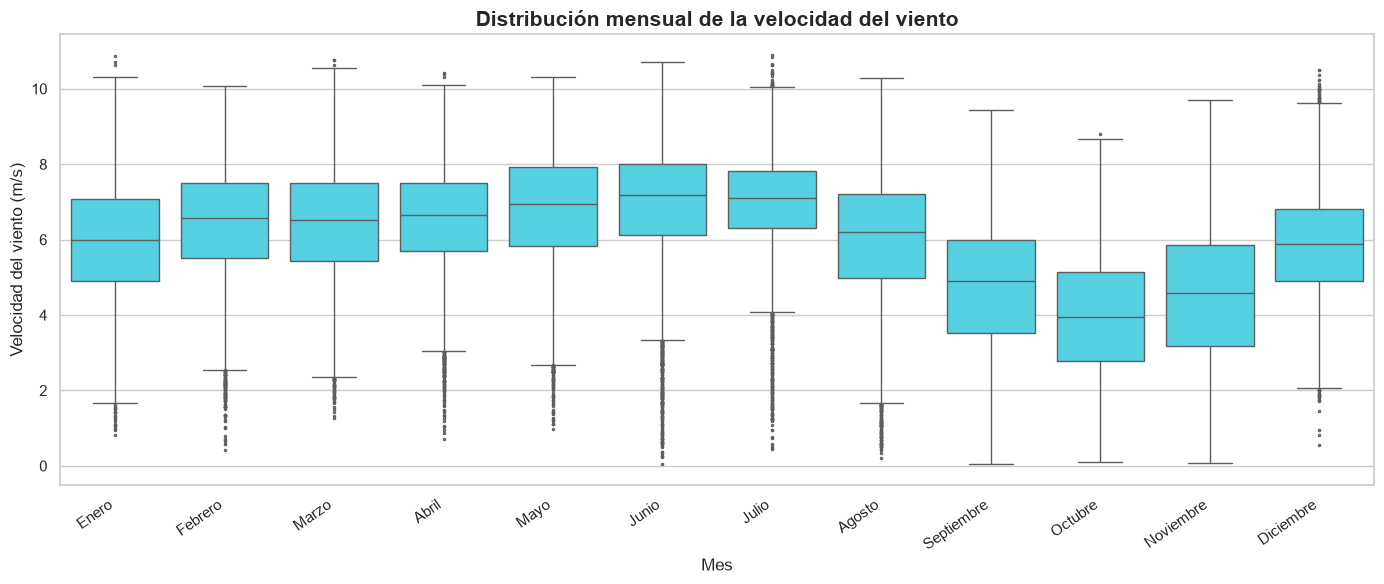

In [42]:
#Boxplot mensual para evaluar la variabilidad
orden_meses = list(nombres_meses.values())
serie_boxplot = analisis.reset_index()
serie_boxplot["Mes"] = serie_boxplot["Mes"].map(nombres_meses)

plt.figure(figsize=(14, 6))
sns.boxplot(
    data=serie_boxplot,
    x="Mes",
    y=variable,
    order=orden_meses,
    color="#3EE2F8",
    fliersize=1.5
)
plt.title("Distribución mensual de la velocidad del viento", fontsize=15, weight="bold")
plt.xlabel("Mes")
plt.ylabel(f"Velocidad del viento ({unidad})")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

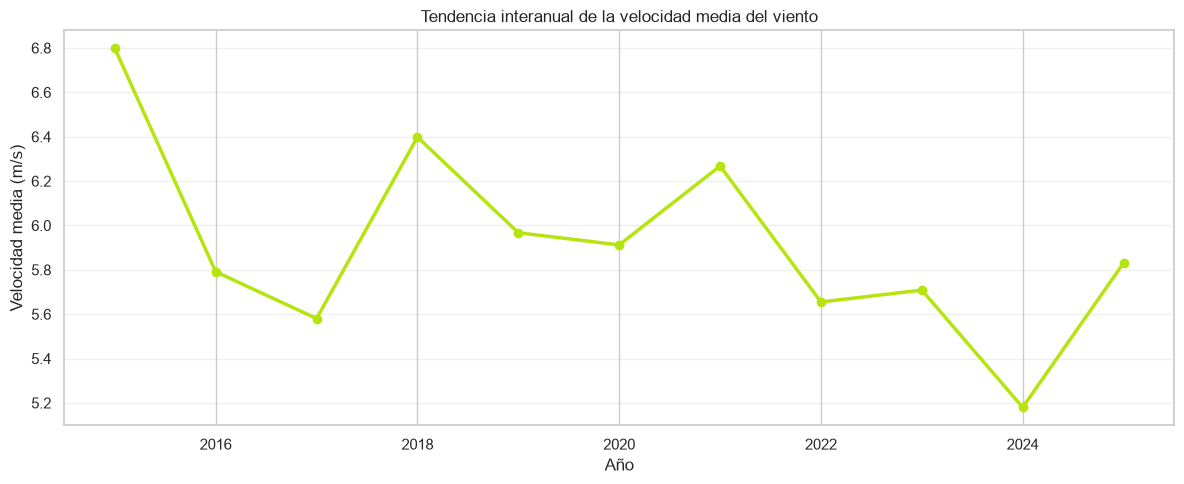

Cambio lineal estimado: -0.073 m/s/año


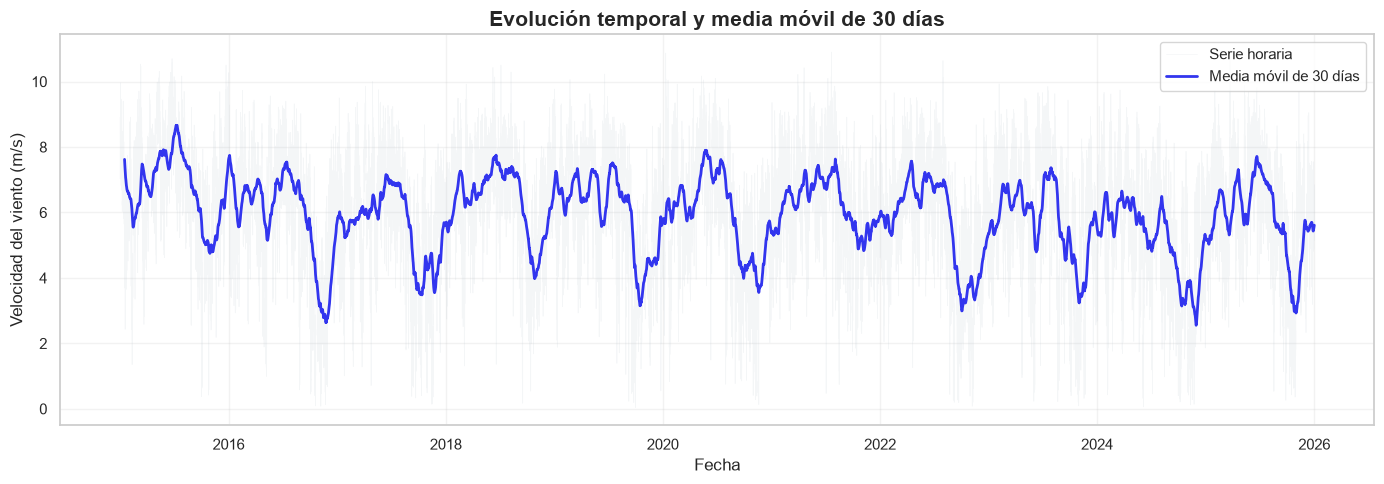

In [44]:
# 7. Tendencia temporal del recurso eólico
promedio_anual["Promedio"].plot(
    figsize=(12, 5),
    marker="o",
    linewidth=2.5,
    color="#B6E40F",
    title="Tendencia interanual de la velocidad media del viento"
)
plt.xlabel("Año")
plt.ylabel(f"Velocidad media ({unidad})")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Tendencia lineal: cuantifica el cambio medio por año.
anios = promedio_anual.index.to_numpy(dtype=float)
valores_anuales = promedio_anual["Promedio"].to_numpy()
pendiente, intercepto = np.polyfit(anios, valores_anuales, 1)
print(f"Cambio lineal estimado: {pendiente:+.3f} {unidad}/año")

# Media móvil de 30 días para visualizar la evolución de la serie horaria.
media_movil = analisis[variable].rolling("30D", min_periods=24 * 15).mean()
plt.figure(figsize=(14, 5))
plt.plot(analisis.index, analisis[variable], color="#B8C4CE", alpha=0.15, linewidth=0.5)
plt.plot(media_movil.index, media_movil, color="#3235EE", linewidth=2)
plt.title("Evolución temporal y media móvil de 30 días", fontsize=15, weight="bold")
plt.xlabel("Fecha")
plt.ylabel(f"Velocidad del viento ({unidad})")
plt.legend(["Serie horaria", "Media móvil de 30 días"])
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Del recurso eólico al potencial de generación eléctrica

Hasta este punto se caracterizó el comportamiento y la variabilidad temporal del recurso eólico (velocidad del viento) en la Alta Guajira: estadísticas descriptivas, promedios mensuales y anuales, meses/años extremos y la tendencia interanual.

Ahora se traduce esa variabilidad en su efecto sobre el **potencial de generación de energía eléctrica**, siguiendo el procedimiento estándar de un estudio de recurso eólico:

1. Extrapolar la velocidad del viento a la altura de buje de un aerogenerador comercial.
2. Ajustar una distribución de Weibull, la herramienta estadística estándar para caracterizar el recurso eólico.
3. Calcular la densidad de potencia eólica disponible.
4. Aplicar una curva de potencia realista para estimar la energía generada, el factor de capacidad y la energía anual producida (AEP).

Como referencia se usa un aerogenerador similar a los instalados en el parque **Guajira I** (Alta Guajira, municipio de Uribia): 10 aerogeneradores Vestas de 2 MW cada uno, con buje a 78 m de altura.

> **Nota metodológica:** `WS2M` mide la velocidad del viento muy cerca del suelo (2 m), por lo que extrapolarla hasta 78 m implica un factor de amplificación considerable. Si se dispone de las variables `WS10M` o `WS50M` de NASA POWER, se recomienda repetir la extrapolación partiendo de esa altura para obtener un resultado más robusto. Los valores obtenidos a continuación deben interpretarse como una aproximación de orden de magnitud, adecuada para fines académicos.

### 1. Extrapolación de la velocidad del viento a la altura de buje

In [ ]:
# Altura de medición de NASA POWER (WS2M) y altura de buje de referencia
altura_medicion = 2   # m
altura_buje = 78      # m (parque Guajira I, aerogeneradores Vestas de 2 MW)
alpha = 0.14          # coeficiente de Hellmann típico para terreno abierto/costero

# Ley exponencial de Hellmann: v2 = v1 * (h2 / h1) ** alpha
analisis["Velocidad_Buje"] = analisis[variable] * (altura_buje / altura_medicion) ** alpha

print(f"Velocidad media a {altura_medicion} m (medida):      {analisis[variable].mean():.2f} {unidad}")
print(f"Velocidad media a {altura_buje} m (extrapolada):     {analisis['Velocidad_Buje'].mean():.2f} {unidad}")
print(f"Factor de amplificación aplicado:                    {(altura_buje/altura_medicion)**alpha:.2f}")

### 2. Ajuste de una distribución de Weibull

In [ ]:
from scipy.stats import weibull_min

# Ajuste de una distribución de Weibull a la velocidad extrapolada.
# floc=0 fija el origen de la distribución en cero (velocidad no negativa).
forma_k, _, escala_c = weibull_min.fit(analisis["Velocidad_Buje"], floc=0)

print(f"Parámetro de forma (k):  {forma_k:.3f}")
print(f"Parámetro de escala (c): {escala_c:.3f} {unidad}")
print(
    "Un valor de k cercano a 2 indica una distribución similar a la de Rayleigh; "
    "valores de k más altos indican un régimen de viento más constante."
)

x = np.linspace(0, analisis["Velocidad_Buje"].max(), 200)
pdf_weibull = weibull_min.pdf(x, forma_k, loc=0, scale=escala_c)

plt.figure(figsize=(10, 5))
plt.hist(
    analisis["Velocidad_Buje"], bins=40, density=True,
    color="#3EE2F8", alpha=0.6, edgecolor="white", label="Datos observados"
)
plt.plot(x, pdf_weibull, color="#B6E40F", linewidth=2.5,
         label=f"Weibull (k={forma_k:.2f}, c={escala_c:.2f})")
plt.title(f"Distribución de la velocidad del viento a {altura_buje} m de altura",
          fontsize=14, weight="bold")
plt.xlabel(f"Velocidad del viento ({unidad})")
plt.ylabel("Densidad de probabilidad")
plt.legend()
plt.tight_layout()
plt.show()

### 3. Densidad de potencia eólica disponible

In [ ]:
# Densidad de potencia eólica disponible (W/m^2)
# Se promedia v^3 (no el cubo del promedio) para no subestimar la energía
# disponible en una serie con variabilidad horaria.
rho = 1.17  # kg/m3, densidad del aire aproximada (clima cálido y costero, ~30 °C, nivel del mar)

analisis["Densidad_Potencia"] = 0.5 * rho * analisis["Velocidad_Buje"] ** 3

print(f"Densidad de potencia eólica media: {analisis['Densidad_Potencia'].mean():.1f} W/m²")

densidad_mensual = (
    analisis.groupby("Mes")["Densidad_Potencia"].mean()
    .rename(index=nombres_meses)
    .reindex(orden_meses)
)

plt.figure(figsize=(12, 5))
densidad_mensual.plot(kind="bar", color="#3235EE")
plt.title("Densidad de potencia eólica media mensual", fontsize=14, weight="bold")
plt.ylabel("Densidad de potencia (W/m²)")
plt.xlabel("Mes")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

### 4. Curva de potencia y estimación de energía generada

In [ ]:
# Curva de potencia de referencia: Vestas V80-2.0 MW (aerogenerador similar
# a los instalados en el parque Guajira I)
v_cutin = 4.0     # m/s, velocidad de arranque
v_rated = 15.0    # m/s, velocidad nominal
v_cutout = 25.0   # m/s, velocidad de parada
potencia_nominal = 2000.0  # kW

def curva_potencia(v, v_cutin=v_cutin, v_rated=v_rated, v_cutout=v_cutout, p_rated=potencia_nominal):
    """Aproximación cúbica de la curva de potencia de un aerogenerador."""
    v = np.asarray(v, dtype=float)
    potencia = np.zeros_like(v)
    en_rango = (v >= v_cutin) & (v < v_rated)
    potencia[en_rango] = p_rated * (v[en_rango] ** 3 - v_cutin ** 3) / (v_rated ** 3 - v_cutin ** 3)
    potencia[(v >= v_rated) & (v <= v_cutout)] = p_rated
    return potencia

analisis["Potencia_kW"] = curva_potencia(analisis["Velocidad_Buje"].to_numpy())

v_plot = np.linspace(0, 30, 300)
plt.figure(figsize=(8, 5))
plt.plot(v_plot, curva_potencia(v_plot), color="#B6E40F", linewidth=2.5)
for v_ref, etiqueta in [(v_cutin, "cut-in"), (v_rated, "nominal"), (v_cutout, "cut-out")]:
    plt.axvline(v_ref, color="gray", linestyle="--", linewidth=1)
    plt.text(v_ref, potencia_nominal * 1.03, etiqueta, ha="center", fontsize=9, color="gray")
plt.title("Curva de potencia de referencia (Vestas V80-2.0 MW)", fontsize=13, weight="bold")
plt.xlabel(f"Velocidad del viento a {altura_buje} m ({unidad})")
plt.ylabel("Potencia generada (kW)")
plt.ylim(0, potencia_nominal * 1.15)
plt.tight_layout()
plt.show()

### 5. Factor de capacidad, energía anual y efecto de la variabilidad temporal

In [ ]:
# Factor de capacidad y energía anual estimada
factor_capacidad = analisis["Potencia_kW"].mean() / potencia_nominal

horas_por_anio = 8760
energia_anual_turbina = analisis["Potencia_kW"].mean() * horas_por_anio / 1000  # MWh/año

num_turbinas = 10  # tamaño de referencia: parque Guajira I (10 x 2 MW = 20 MW)
energia_anual_parque = energia_anual_turbina * num_turbinas

print(f"Factor de capacidad estimado:            {factor_capacidad * 100:.1f} %")
print(f"Energía anual estimada por aerogenerador: {energia_anual_turbina:,.0f} MWh/año")
print(
    f"Energía anual estimada del parque de referencia "
    f"({num_turbinas} aerogeneradores, {num_turbinas * potencia_nominal / 1000:.0f} MW): "
    f"{energia_anual_parque:,.0f} MWh/año"
)

In [ ]:
# Factor de capacidad mensual y anual: conecta la variabilidad temporal del
# recurso eólico con la variabilidad del potencial de generación eléctrica.
cf_mensual = (
    analisis.groupby("Mes")["Potencia_kW"].mean() / potencia_nominal
).rename(index=nombres_meses).reindex(orden_meses)

cf_anual = analisis.groupby("Año")["Potencia_kW"].mean() / potencia_nominal

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

cf_mensual.plot(kind="bar", ax=ax[0], color="#3EE2F8")
ax[0].set_title("Factor de capacidad medio mensual")
ax[0].set_ylabel("Factor de capacidad")
ax[0].set_xlabel("Mes")
ax[0].tick_params(axis="x", rotation=35)

cf_anual.plot(marker="o", ax=ax[1], color="#B6E40F", linewidth=2.5)
ax[1].set_title("Factor de capacidad medio anual")
ax[1].set_ylabel("Factor de capacidad")
ax[1].set_xlabel("Año")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Mes de mayor factor de capacidad: {cf_mensual.idxmax()} ({cf_mensual.max()*100:.1f} %)")
print(f"Mes de menor factor de capacidad: {cf_mensual.idxmin()} ({cf_mensual.min()*100:.1f} %)")

## Conclusiones

**Comportamiento y variabilidad temporal del recurso eólico**

- El periodo analizado (2015-2025, base horaria) muestra una velocidad media del viento de 5.92 m/s a 2 m de altura, con un coeficiente de variación de aproximadamente 31 %, lo que indica una variabilidad moderada-alta del recurso.
- El mes con mayor velocidad media fue julio (6.99 m/s) y el de menor velocidad fue octubre (3.98 m/s), un patrón coherente con la influencia de los vientos alisios del noreste, que se intensifican en la temporada seca y se debilitan hacia el segundo semestre del año, cuando se aproxima la temporada de lluvias en el Caribe colombiano.
- A nivel interanual, 2015 registró el promedio más alto (6.80 m/s) y 2024 el más bajo (5.18 m/s); la tendencia lineal estimada es de -0.073 m/s por año, es decir, una leve disminución del recurso en el periodo analizado.

**Efecto sobre el potencial de generación de energía eléctrica**

- Al extrapolar la velocidad a la altura de buje (78 m) y ajustar una distribución de Weibull, se obtuvieron los parámetros k = _____ y c = _____ m/s *(completa estos valores con el resultado de la celda correspondiente al ejecutar el notebook)*.
- La densidad de potencia eólica media resultó de _____ W/m², con los valores más altos en los meses de mayor velocidad del viento y los más bajos en los meses de viento débil, mostrando que la variabilidad estacional del viento se traslada directamente a la variabilidad del recurso energético disponible.
- Usando como referencia un aerogenerador Vestas V80-2.0 MW (como los del parque Guajira I), el factor de capacidad estimado fue de _____ %, con una energía anual aproximada de _____ MWh por aerogenerador. Este valor debe compararse con el rango típico de proyectos eólicos en operación en Colombia (usualmente entre 30 % y 45 % en la Alta Guajira) para evaluar la viabilidad del sitio analizado.
- El factor de capacidad mensual reproduce el mismo patrón estacional que la velocidad del viento: los meses de menor recurso presentan una menor generación esperada, lo que evidencia que la intermitencia del recurso eólico se traduce directamente en intermitencia de la generación eléctrica. Esto tiene implicaciones prácticas para la operación del sistema: la necesidad de complementariedad con otras fuentes (p. ej. energía hidráulica o solar), el dimensionamiento de almacenamiento, y la gestión de la variabilidad en la planeación energética del departamento.
- La leve tendencia decreciente en la velocidad media anual, de confirmarse con series más largas o con datos adicionales, resalta la importancia de monitorear el recurso a largo plazo antes de dimensionar nuevos proyectos, en lugar de basarse únicamente en años puntuales de referencia.

> **Nota:** completa los espacios en blanco anteriores con los valores numéricos que arrojen las celdas de este notebook al ejecutarlo en tu propio entorno (se requiere conexión a internet para consultar la API de NASA POWER).